In [ ]:
import re, os
import numpy as np, pandas as pd
import pyarrow.parquet as pq
import lsdb
from lsdb.streams import CatalogStream
from huggingface_hub import HfApi, hf_hub_download

REPO = "UniverseTBD/mmu_ssl_legacysurvey_north"
BASE = "mmu_ssl_legacysurvey_north/dataset/" 
api  = HfApi()

legacy_scalar = lsdb.open_catalog(
    f"hf://datasets/{REPO}",
    columns=["object_id", "ra", "dec"],
)
prov_scalar = lsdb.open_catalog(
    "hf://datasets/UniverseTBD/mmu_desi_provabgs",
    columns=["object_id", "ra", "dec", "LOG_MSTAR", "Z_HP", "AVG_SFR", "TAGE_MW", "Z_MW"],
)

xm = legacy_scalar.crossmatch(prov_scalar, radius_arcsec=0.1, n_neighbors=1)

batch, n = [], 0
for chunk in CatalogStream(catalog=xm):
    if len(chunk):
        batch.append(chunk); n += len(chunk)
    if n >= 2000:
        break

matches = pd.concat(batch).head(2000).reset_index()
matches.to_parquet("sample_2k_matches_metadata.parquet")
print(len(matches), matches.columns.tolist())

/Users/gaurav/Desktop/Astrobridge/env/lib/python3.13/site-packages/lsdb/catalog/catalog.py:410: FutureWarning: The default suffix behavior will change from applying suffixes to all columns to only applying suffixes to overlapping columns in a future release.To maintain the current behavior, explicitly set `suffix_method='all_columns'`. To change to the new behavior, set `suffix_method='overlapping_columns'`.
  warnings.warn(


2000 ['_healpix_29', 'object_id_mmu_ssl_legacysurvey_north', 'ra_mmu_ssl_legacysurvey_north', 'dec_mmu_ssl_legacysurvey_north', 'object_id_mmu_desi_provabgs', 'ra_mmu_desi_provabgs', 'dec_mmu_desi_provabgs', 'LOG_MSTAR_mmu_desi_provabgs', 'Z_HP_mmu_desi_provabgs', 'AVG_SFR_mmu_desi_provabgs', 'TAGE_MW_mmu_desi_provabgs', 'Z_MW_mmu_desi_provabgs', '_dist_arcsec']


In [7]:
print(matches["_dist_arcsec"].describe())

count    2000.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: _dist_arcsec, dtype: double[pyarrow]


In [8]:
pixels = legacy_scalar.get_healpix_pixels()
orders = sorted({p.order for p in pixels})
known  = {(p.order, p.pixel) for p in pixels}

def partition_of(hp29):
    for o in orders:
        key = (o, hp29 >> (2 * (29 - o)))
        if key in known:
            return key

matches["_part"] = matches["_healpix_29"].map(partition_of)
assert matches["_part"].notna().all(), "some rows mapped to no partition"
print(matches.groupby("_part").size())

_part
(6, 10154)     536
(6, 10513)    1191
(6, 11405)      81
(6, 11523)     192
dtype: int64


In [9]:
pat = re.compile(r"Norder=(\d+)/Dir=\d+/Npix=(\d+)\.parquet$")

path_by_pixel = {}
for f in api.list_repo_files(REPO, repo_type="dataset"):
    if not f.startswith(BASE):
        continue
    m = pat.search(f)
    if m:
        key = (int(m.group(1)), int(m.group(2)))
        assert key not in path_by_pixel, f"ambiguous: {f}"
        path_by_pixel[key] = f

info  = api.repo_info(REPO, repo_type="dataset", files_metadata=True)
sizes = {s.rfilename: s.size for s in info.siblings}

for part in matches["_part"].unique():
    p = path_by_pixel[part]
    assert "_10arcs" not in p
    print(part, p, round(sizes[p] / 1e9, 2), "GB")

(np.int64(6), np.int64(11405)) mmu_ssl_legacysurvey_north/dataset/Norder=6/Dir=10000/Npix=11405.parquet 0.7 GB
(np.int64(6), np.int64(10513)) mmu_ssl_legacysurvey_north/dataset/Norder=6/Dir=10000/Npix=10513.parquet 0.63 GB
(np.int64(6), np.int64(11523)) mmu_ssl_legacysurvey_north/dataset/Norder=6/Dir=10000/Npix=11523.parquet 0.65 GB
(np.int64(6), np.int64(10154)) mmu_ssl_legacysurvey_north/dataset/Norder=6/Dir=10000/Npix=10154.parquet 0.76 GB


In [10]:
os.makedirs("cutouts", exist_ok=True)

# smallest file first, so failures surface cheaply
parts = sorted(matches["_part"].unique(), key=lambda p: sizes[path_by_pixel[p]])

for part in parts:
    wanted = set(matches.loc[matches["_part"] == part, "_healpix_29"])
    if all(os.path.exists(f"cutouts/{h}.npy") for h in wanted):
        print(part, "cached"); continue

    local = hf_hub_download(REPO, path_by_pixel[part],
                            repo_type="dataset", local_dir="hats_tmp")
    try:
        pf = pq.ParquetFile(local)
        for rg in range(pf.num_row_groups):
            idx = pf.read_row_group(rg, columns=["_healpix_29"])["_healpix_29"].to_pylist()
            hits = [i for i, h in enumerate(idx) if h in wanted]
            if not hits:
                continue
            imgs = pf.read_row_group(rg, columns=["image"])["image"].to_pylist()
            for i in hits:
                np.save(f"cutouts/{idx[i]}.npy", np.asarray(imgs[i]))
            del imgs
        del pf
    finally:
        os.remove(local)

    found = sum(1 for h in wanted if os.path.exists(f"cutouts/{h}.npy"))
    print(part, f"— {found}/{len(wanted)}")
    assert found > 0, f"{part}: matched no rows"

(np.int64(6), np.int64(10513)) — 1191/1191
(np.int64(6), np.int64(11523)) — 192/192
(np.int64(6), np.int64(11405)) — 81/81
(np.int64(6), np.int64(10154)) — 536/536


In [11]:
meta = pd.read_parquet("sample_2k_matches_metadata.parquet").set_index("_healpix_29", drop=False)
obj = np.load(f"cutouts/{meta['_healpix_29'].iloc[0]}.npy", allow_pickle=True)
print("dtype:", obj.dtype, "shape:", obj.shape)

item = obj.item() if obj.shape == () else obj[0]
print("type:", type(item))
if isinstance(item, dict):
    for k, v in item.items():
        print(f"  {k}: {type(v).__name__}", np.shape(v))
else:
    print("len:", len(item), "first:", type(item[0]), np.shape(item[0]))

dtype: object shape: ()
type: <class 'dict'>
  band: list (3,)
  flux: list (3, 152, 152)
  psf_fwhm: list (3,)
  scale: list (3,)


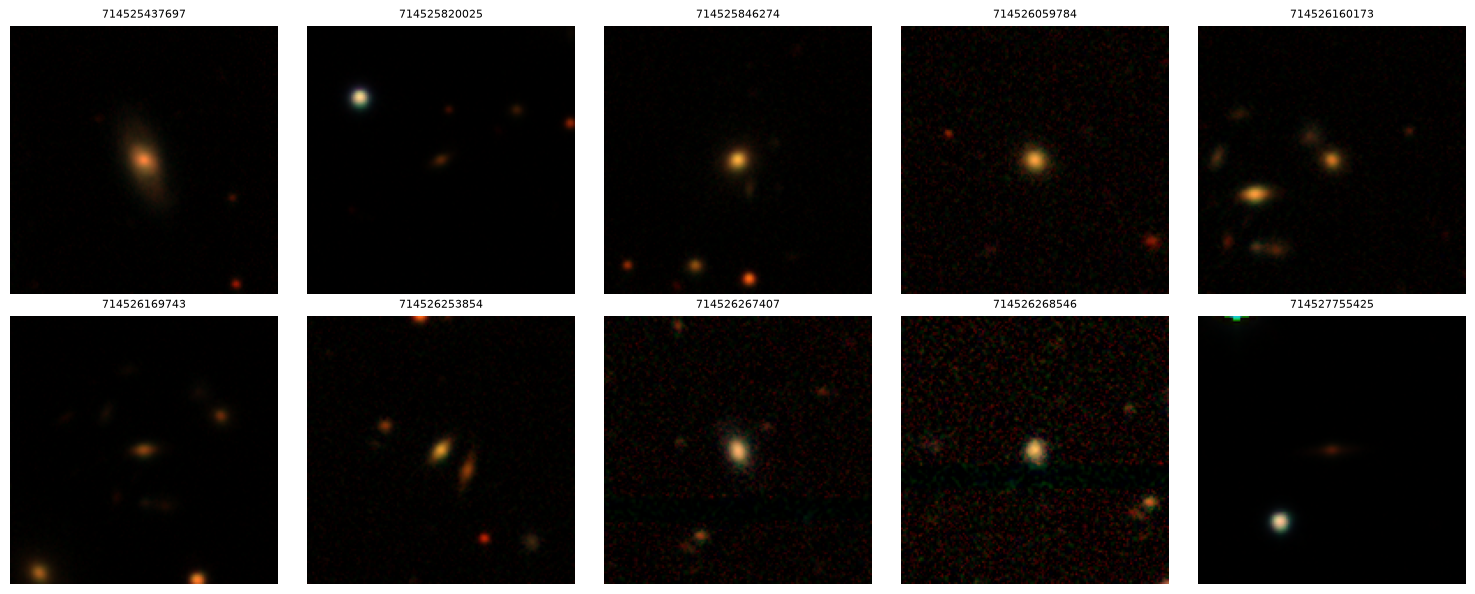

In [ ]:
# Simply viewing a sample
# ruff:noqa
import glob
import numpy as np
import matplotlib.pyplot as plt

files = sorted(glob.glob("cutouts/*.npy"))[:10]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, f in zip(axes.ravel(), files):
    g, r, z = np.asarray(np.load(f, allow_pickle=True).item()["flux"], dtype=np.float32)

    rgb = np.stack([g, r, z], axis=-1)
    rgb = np.arcsinh(rgb / np.percentile(rgb, 99.5))
    rgb = np.clip(rgb / rgb.max(), 0, 1)

    ax.imshow(rgb, origin="lower")
    ax.set_title(f.split("/")[-1][:12], fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()